100%|██████████| 28.7M/28.7M [00:00<00:00, 177MB/s]

Extracting files...


Dataset Loaded Successfully

Region Analysis:
                             Total_Attacks  Average_Fatalities  \
region_txt                                                       
Australasia & Oceania                  282            0.543478   
Central America & Caribbean          10344            3.578659   
Central Asia                           563            1.788909   
East Asia                              802            1.509830   
Eastern Europe                        5144            1.489554   
Middle East & North Africa           50474            2.855584   
North America                         3456            1.461790   
South America                        18978            1.666994   
South Asia                           44974            2.300770   
Southeast Asia                       12485            1.280776   
Sub-Saharan Africa                   17550            4.918492   
Western Europe                       16639            0.425637   

                             

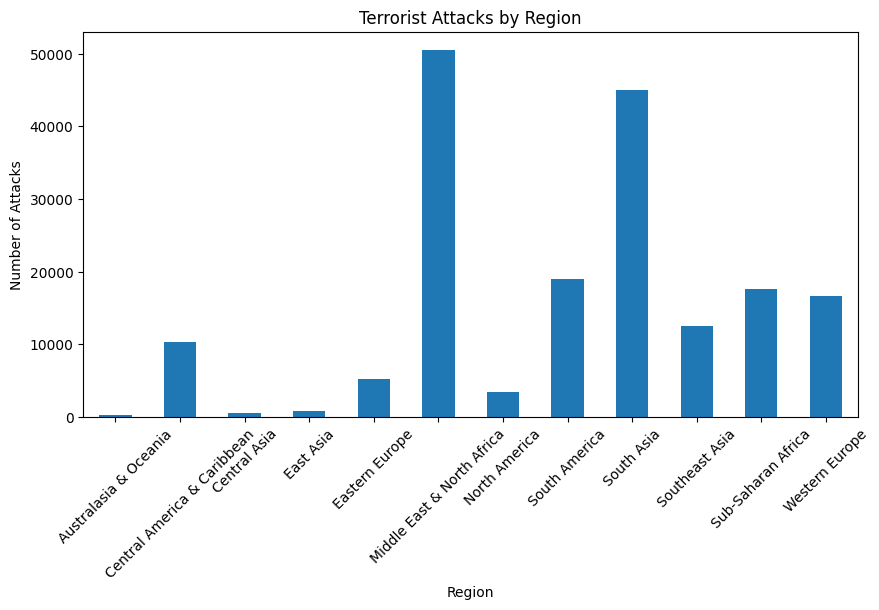

In [1]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import os

# ============================================================
# LOAD GLOBAL TERRORISM DATASET
# ============================================================

path = kagglehub.dataset_download("START-UMD/gtd")

csv_file = [f for f in os.listdir(path) if f.endswith(".csv")][0]

df = pd.read_csv(
    os.path.join(path, csv_file),
    encoding="latin1",
    low_memory=False
)

print("Dataset Loaded Successfully")

# ============================================================
# 1. GROUP BY REGION
# ============================================================

region_analysis = df.groupby("region_txt").agg(
    Total_Attacks=("eventid", "count"),
    Average_Fatalities=("nkill", "mean"),
    Average_Wounded=("nwound", "mean")
)

print("\nRegion Analysis:")
print(region_analysis)

# ============================================================
# 2. ATTACK ANALYSIS BY REGION
# ============================================================

attack_analysis = pd.crosstab(
    df["region_txt"],
    df["attacktype1_txt"]
)

print("\nAttack Type by Region:")
print(attack_analysis)

# ============================================================
# 3. GROUP BY ATTACK TYPE
# ============================================================

attack_type_analysis = df.groupby("attacktype1_txt").agg(
    Total_Attacks=("eventid", "count"),
    Average_Fatalities=("nkill", "mean"),
    Average_Wounded=("nwound", "mean")
)

print("\nAttack Type Analysis:")
print(attack_type_analysis)

# ============================================================
# 4. BAR CHART
# ============================================================

region_analysis["Total_Attacks"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Terrorist Attacks by Region")
plt.xlabel("Region")
plt.ylabel("Number of Attacks")
plt.xticks(rotation=45)

plt.show()